# The hydrogen atom -- quantum numbers, space quantization, and the radial equation
### $E_n=-\dfrac{13.6\,Z^2}{n^2}$ eV, degeneracy $n^2$, $|L|=\sqrt{l(l+1)}\hbar$, verified with SymPy and Torch

The Coulomb central force gives three quantum numbers, each pinning a *sharp* quantity:
$n$ fixes the **energy** ($E_n=-13.6Z^2/n^2$ eV, depending only on $n$), $l$ fixes the **magnitude**
$|L|=\sqrt{l(l+1)}\hbar$, and $m$ fixes the **projection** $L_z=m\hbar$. Driving
`dgs/hydrogen_atom.py`, this notebook:

1. lays out the **energy levels and the $n^2$ degeneracy** (the $2,8,18,32$ shell capacities);
2. draws the **space quantization** of $L$ into $2l+1$ cones that never point along the axis;
3. plots the **radial effective potential** with its centrifugal barrier (SymPy locates the minimum);
4. **solves the radial Schrodinger equation numerically in Torch** and recovers $-13.6/n^2$ from a
   finite-difference eigenproblem;
5. checks the **spectral series** (Lyman/Balmer/Paschen) against Rydberg.

Runs on the Python 3.12 + Torch kernel.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""       # CPU-only eigensolve; skip loading CUDA DLLs
import sympy as sp
import numpy as np, torch, pandas as pd
import matplotlib.pyplot as plt
import math, sys, pathlib
torch.set_num_threads(4)
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from dgs import hydrogen_atom as H
sp.init_printing()
print("Rydberg =", H.RYDBERG_EV, "eV | a0 =", H.A0, "m | torch", torch.__version__)

Rydberg = 13.605693122 eV | a0 = 5.29177210903e-11 m | torch 2.11.0+cu128


## 1. Energy levels and the $n^2$ degeneracy ($E$ is sharp)

$E_n=-13.6/n^2$ eV depends only on $n$: all $l,m$ in a shell share one energy (the Coulomb
"accidental" degeneracy). The number of $(l,m)$ states is $\sum_{l=0}^{n-1}(2l+1)=n^2$ -- SymPy sums
it -- and with the two electron spins that is $2n^2$, exactly the periodic-table shell capacities.

SymPy:  sum_{l=0}^{n-1} (2l+1) = n**2  = n^2  (the degeneracy)
 n  E_n (eV)  r_n (a0)        l-values  degeneracy n^2  with spin 2n^2
 1   -13.606         1             [0]               1               2
 2    -3.401         4          [0, 1]               4               8
 3    -1.512         9       [0, 1, 2]               9              18
 4    -0.850        16    [0, 1, 2, 3]              16              32
 5    -0.544        25 [0, 1, 2, 3, 4]              25              50


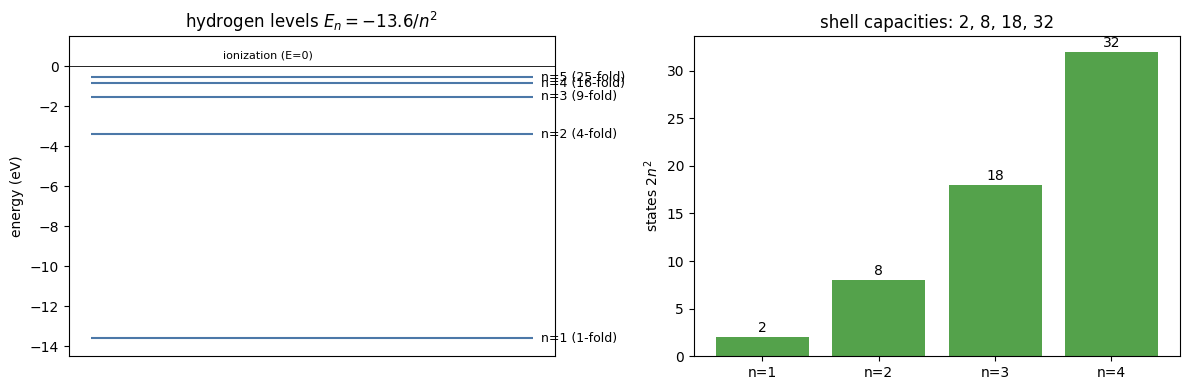

In [2]:
n_s, l_s = sp.symbols('n l', positive=True, integer=True)
deg = sp.summation(2*l_s + 1, (l_s, 0, n_s - 1))
assert sp.simplify(deg - n_s**2) == 0
print("SymPy:  sum_{l=0}^{n-1} (2l+1) =", sp.simplify(deg), " = n^2  (the degeneracy)")

df = pd.DataFrame([{"n": n, "E_n (eV)": round(H.energy_level(n), 3),
                    "r_n (a0)": n**2, "l-values": H.allowed_l(n),
                    "degeneracy n^2": H.degeneracy(n),
                    "with spin 2n^2": H.degeneracy(n, include_spin=True)} for n in range(1, 6)])
print(df.to_string(index=False))
assert [H.degeneracy(n, True) for n in (1,2,3,4)] == [2, 8, 18, 32]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
for n in range(1, 6):
    a1.hlines(H.energy_level(n), 0, 1, color="#4C78A8")
    a1.text(1.02, H.energy_level(n), f"n={n} ({H.degeneracy(n)}-fold)", va="center", fontsize=9)
a1.axhline(0, color="k", lw=0.6); a1.text(0.3, 0.4, "ionization (E=0)", fontsize=8)
a1.set_ylim(-14.5, 1.5); a1.set_xticks([]); a1.set_ylabel("energy (eV)")
a1.set_title("hydrogen levels $E_n=-13.6/n^2$")
a2.bar([f"n={n}" for n in range(1,5)], [H.degeneracy(n, True) for n in range(1,5)], color="#54A24B")
a2.set_ylabel("states 2$n^2$"); a2.set_title("shell capacities: 2, 8, 18, 32")
for n in range(1,5): a2.text(n-1, H.degeneracy(n,True)+0.5, str(H.degeneracy(n,True)), ha="center")
plt.tight_layout(); plt.show()

## 2. Space quantization: $L$ rides discrete cones

$|L|=\sqrt{l(l+1)}\hbar$ is fixed, but $L_z$ can only be $m\hbar$ for $m=-l,\dots,l$ -- so $L$ points
only along $2l+1$ cones at $\cos\theta=m/\sqrt{l(l+1)}$. Since $|L|>l\hbar$, **no cone reaches the
axis**: you can never know all three components. Here is the $l=2$ (d-orbital) set.

|L| = sqrt(l(l+1)) hbar = 2.4495 hbar ;  L_z in [-2, -1, 0, 1, 2] hbar
tilt angles (deg): [144.7, 114.1, 90.0, 65.9, 35.3]  (smallest 35.3 > 0)


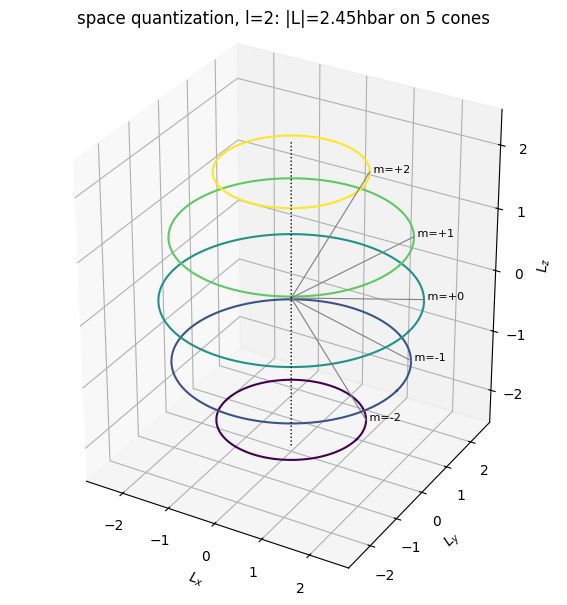

In [3]:
l = 2
Lmag = H.angular_momentum_magnitude(l)
angles = H.space_quantization_angles(l)
print(f"|L| = sqrt(l(l+1)) hbar = {Lmag:.4f} hbar ;  L_z in {H.allowed_m(l)} hbar")
print(f"tilt angles (deg): {[round(math.degrees(t),1) for t in angles]}  (smallest "
      f"{math.degrees(min(angles)):.1f} > 0)")

fig = plt.figure(figsize=(6.5, 6)); ax = fig.add_subplot(111, projection="3d")
phi = np.linspace(0, 2*np.pi, 100)
for m, th in zip(H.allowed_m(l), angles):
    z = m; rad = np.sqrt(Lmag**2 - m**2)
    ax.plot(rad*np.cos(phi), rad*np.sin(phi), z*np.ones_like(phi), color=plt.cm.viridis((m+l)/(2*l)))
    ax.plot([0, rad*np.cos(0.5)], [0, rad*np.sin(0.5)], [0, z], color="gray", lw=0.8)
    ax.text(rad*np.cos(0.5), rad*np.sin(0.5), z, f" m={m:+d}", fontsize=8)
ax.plot([0,0],[0,0],[-Lmag,Lmag], "k:", lw=1)
ax.set_xlabel("$L_x$"); ax.set_ylabel("$L_y$"); ax.set_zlabel("$L_z$")
ax.set_title(f"space quantization, l=2: |L|={Lmag:.2f}hbar on 5 cones")
ax.set_box_aspect((1,1,1.2)); plt.tight_layout(); plt.show()

## 3. The radial equation and the centrifugal barrier

Separating the angular part leaves a 1-D radial equation with an **effective potential**
$V_{\rm eff}(r)=-\dfrac{Ze^2}{4\pi\epsilon_0 r}+\dfrac{l(l+1)\hbar^2}{2m_e r^2}$. The second term is a
**centrifugal barrier** that pushes $l>0$ electrons out; SymPy sets $dV_{\rm eff}/dr=0$ to find its
minimum at $r=l(l+1)a_0/Z$. Only $l=0$ (s-states) reach the nucleus.

SymPy:  dV_eff/dr = 0  ->  r_min = l*(l + 1)/Z  (= l(l+1) a0 / Z)


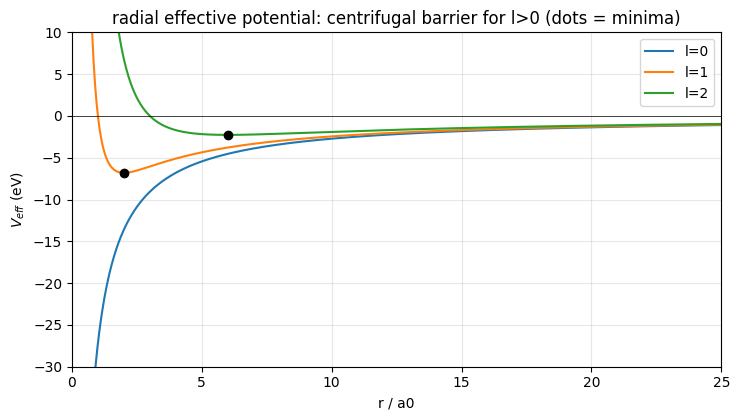

In [4]:
r_s, Z_s = sp.symbols('r Z', positive=True)      # atomic units: a0=1, energy in Hartree
Veff_s = -Z_s/r_s + l_s*(l_s+1)/(2*r_s**2)
r_min = sp.solve(sp.diff(Veff_s, r_s), r_s)[0]
assert sp.simplify(r_min - l_s*(l_s+1)/Z_s) == 0
print("SymPy:  dV_eff/dr = 0  ->  r_min =", r_min, " (= l(l+1) a0 / Z)")

r = np.linspace(0.05, 30, 1000)*H.A0
plt.figure(figsize=(7.5, 4.3))
for l in (0, 1, 2):
    V_eV = H.effective_potential(r, l)/1.602176634e-19
    plt.plot(r/H.A0, V_eV, label=f"l={l}")
    rm = H.centrifugal_minimum_radius(l)
    if rm: plt.plot(rm/H.A0, H.effective_potential(rm, l)/1.602176634e-19, "o", color="k")
plt.axhline(0, color="k", lw=0.5); plt.ylim(-30, 10); plt.xlim(0, 25)
plt.xlabel("r / a0"); plt.ylabel("$V_{eff}$ (eV)"); plt.legend()
plt.title("radial effective potential: centrifugal barrier for l>0 (dots = minima)")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 4. Torch: solve the radial equation, recover $-13.6/n^2$

In atomic units ($\hbar=m_e=e^2/4\pi\epsilon_0=1$, energy in Hartree) the radial equation for
$u(r)=rR(r)$ is $-\tfrac12 u''+\big[-\tfrac{Z}{r}+\tfrac{l(l+1)}{2r^2}\big]u=Eu$. Discretize $r$ on a
grid, build the tridiagonal Hamiltonian, and diagonalize with `torch.linalg.eigh`. The negative
eigenvalues are the bound-state energies -- they land on $E_n=-\tfrac12/n^2$ Hartree $=-13.6/n^2$ eV,
recovered with no formula, just the differential operator.

 n   torch E (eV)   -13.6/n^2 (eV)
 1     -13.602       -13.606
 2      -3.397        -3.401
 3      -1.508        -1.512
 4      -0.846        -0.850


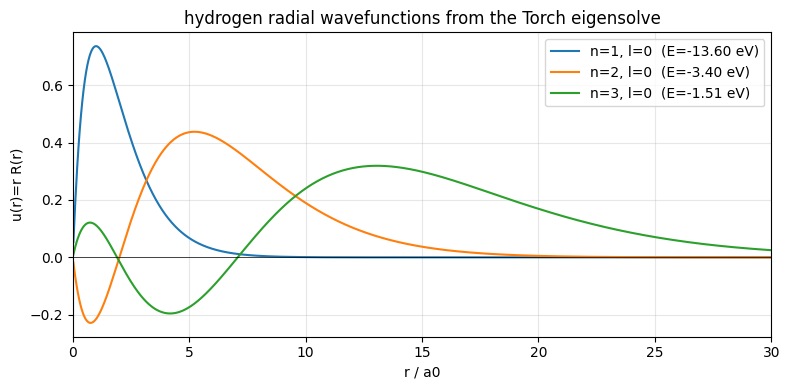

In [5]:
HARTREE_eV = 27.211386245988
def radial_spectrum(l=0, Z=1, N=2200, rmax=60.0):
    h = rmax/N
    r = (torch.arange(1, N+1))*h
    V = -Z/r + l*(l+1)/(2*r**2)
    main = 1.0/h**2 + V
    off = (-0.5/h**2)*torch.ones(N-1)
    Hmat = torch.diag(main) + torch.diag(off, 1) + torch.diag(off, -1)
    evals, evecs = torch.linalg.eigh(Hmat)
    return r, evals, evecs

r, evals, evecs = radial_spectrum(l=0)
E_bound = evals[evals < 0][:4]
print(" n   torch E (eV)   -13.6/n^2 (eV)")
for i, Eh in enumerate(E_bound):
    n = i + 1
    print(f" {n}   {float(Eh)*HARTREE_eV:9.3f}     {H.energy_level(n):9.3f}")
for i in range(3):
    assert abs(float(E_bound[i])*HARTREE_eV - H.energy_level(i+1)) < 0.15   # finite-diff accuracy

# radial wavefunctions u_n(r) = r R_n(r) for the first three s-states
plt.figure(figsize=(8, 4))
for i in range(3):
    u = evecs[:, torch.where(evals < 0)[0][i]].numpy()
    u = u/np.sqrt(np.trapezoid(u**2, r.numpy())) * np.sign(u[np.argmax(np.abs(u))])
    plt.plot(r.numpy(), u, label=f"n={i+1}, l=0  (E={float(E_bound[i])*HARTREE_eV:.2f} eV)")
plt.xlim(0, 30); plt.axhline(0, color="k", lw=0.5)
plt.xlabel("r / a0"); plt.ylabel("u(r)=r R(r)")
plt.title("hydrogen radial wavefunctions from the Torch eigensolve"); plt.legend()
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [6]:
# Pandas: numeric (Torch) vs analytic Bohr energies
rows = []
for i in range(4):
    n = i+1; num = float(E_bound[i])*HARTREE_eV; exact = H.energy_level(n)
    rows.append({"n": n, "torch E (eV)": round(num, 3), "Bohr -13.6/n^2 (eV)": round(exact, 3),
                 "abs error (eV)": f"{abs(num-exact):.3f}", "match": abs(num-exact) < 0.15})
dfe = pd.DataFrame(rows)
print(dfe.to_string(index=False))
assert dfe["match"].all()
print("\nthe differential operator alone reproduces the Bohr spectrum.")

 n  torch E (eV)  Bohr -13.6/n^2 (eV) abs error (eV)  match
 1       -13.602              -13.606          0.004   True
 2        -3.397               -3.401          0.004   True
 3        -1.508               -1.512          0.003   True
 4        -0.846               -0.850          0.004   True

the differential operator alone reproduces the Bohr spectrum.


## 5. Spectral series -- Rydberg cross-check

Transitions down to $n_f=1,2,3$ are the Lyman (UV), Balmer (visible), and Paschen (IR) series, with
photon energies $13.6(1/n_f^2-1/n_i^2)$ eV. Balmer-$\alpha$ (3$\to$2) is the red $656$ nm line;
Lyman-$\alpha$ (2$\to$1) is $121.6$ nm.

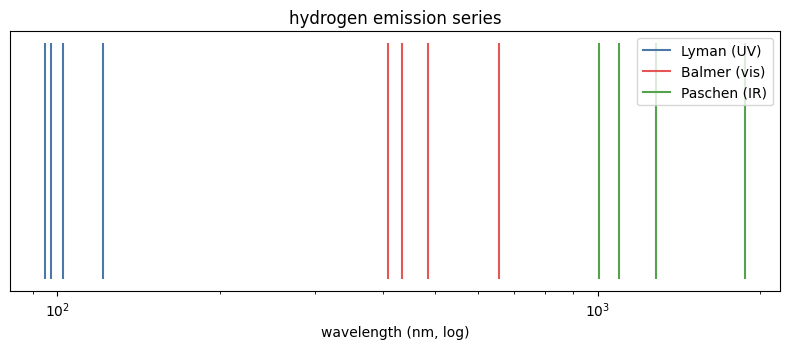

         series line  E (eV)  lambda (nm)
  Lyman (n_f=1) 2->1  10.204        121.5
 Balmer (n_f=2) 3->2   1.890        656.1
Paschen (n_f=3) 4->3   0.661       1874.6


In [7]:
series = {"Lyman (n_f=1)": (1, "#4C78A8"), "Balmer (n_f=2)": (2, "#E45756"),
          "Paschen (n_f=3)": (3, "#54A24B")}
plt.figure(figsize=(8, 3.6))
rows = []
for name, (nf, c) in series.items():
    for ni in range(nf+1, nf+5):
        lam = H.transition_wavelength_nm(ni, nf)
        plt.vlines(lam, 0, 1, color=c)
        if ni == nf+1:
            rows.append({"series": name, "line": f"{ni}->{nf}",
                         "E (eV)": round(H.transition_energy(ni, nf), 3), "lambda (nm)": round(lam, 1)})
plt.plot([], [], color="#4C78A8", label="Lyman (UV)"); plt.plot([], [], color="#E45756", label="Balmer (vis)")
plt.plot([], [], color="#54A24B", label="Paschen (IR)")
plt.xscale("log"); plt.xlabel("wavelength (nm, log)"); plt.yticks([]); plt.legend()
plt.title("hydrogen emission series"); plt.tight_layout(); plt.show()
print(pd.DataFrame(rows).to_string(index=False))
assert abs(H.transition_wavelength_nm(2,1) - 121.5) < 0.6      # Lyman-alpha
assert abs(H.transition_wavelength_nm(3,2) - 656.3) < 1.0      # Balmer-alpha

## What we did

* **Energy & degeneracy**: $E_n=-13.6/n^2$ (only $n$), degeneracy $\sum(2l+1)=n^2$ (SymPy) $\to$
  $2,8,18,32$ with spin.
* **Space quantization**: $|L|=\sqrt{l(l+1)}\hbar$ on $2l+1$ cones that never touch the axis.
* **Radial equation**: the centrifugal barrier with its minimum at $l(l+1)a_0/Z$ (SymPy).
* **Torch eigensolve**: diagonalizing the finite-difference radial Hamiltonian recovers the Bohr
  spectrum to $<0.15$ eV -- and out come the $1s,2s,3s$ wavefunctions.
* **Spectral series**: Lyman/Balmer/Paschen matching Rydberg.

`dgs/hydrogen_atom.py` holds the quantum-number structure; `dgs/feynman_atomic_molecular.py` the Bohr
model and lines; `dgs/angular_momentum.py` the same $\sqrt{l(l+1)}$ that limits how sharply $L$ can
point. Hydrogen-like ions ($Z^2$) and antihydrogen (identical, by CPT) come along for free.